In [1]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import aplpy

import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch

sys.path.append("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/process_tools")
from cut_resize_tools import *
from Astronomy import *

In [2]:
fits_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_01700+0000_2x2_12CO_v1.00_cube.fits"
integ_fits_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/FUGIN/mom0/FGN_01700+0000_2x2_12CO_v1.00_cube.pk_vsmooth_2.0_xysmooth_2.0_thresh_700.0_sigma_3.0_mom0.fits"

integ_hdu = fits.open(integ_fits_path)[0]
hdu = fits.open(fits_path)[0]
wcs = WCS(integ_hdu.header)

raw_d = hdu.data
header = hdu.header

In [75]:
vsmooth = 5
thresh = 1
sigma = 8
sch_rms = 10
ech_rms = 50
sch_ii = 160
ech_ii = 220
percentile = 99.997
width_half = 30
sigma_multiply = None
# width = 60

# cut_size_list = [256, 128, 64]
integrate_layer_num = 30
obj_size = 100
maximum_mode = "percentile"

In [63]:
catalogue_path = '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/infer_catalogue_all.csv' # 提供されたCSVファイル
catalogue_data = pd.read_csv(catalogue_path)

In [5]:
catalogue_data['GLON_center'] = (catalogue_data['ra_min'] + catalogue_data['ra_max']) / 2
catalogue_data['GLAT_center'] = (catalogue_data['dec_min'] + catalogue_data['dec_max']) / 2

In [6]:
ny, nx = raw_d.shape[1:3]
glon_min, glat_min = wcs.all_pix2world(nx, 0, 0)
glon_max, glat_max = wcs.all_pix2world(0, ny, 0)

# fitsが担当する領域を調整
#  FGN_01100➡️l=10°~12°→10°~11.5°
#  FGN_01200➡️l=11°~13°→11.5°~12.5°
#  FGN_01300➡️l=12°~14°→12.5°~13.5°
# ……

if glon_min > 10:
    glon_min += 0.5
glon_max -= 0.5

print("glon_min: ", glon_min,"\n",
      "glon_max: ", glon_max,"\n",
      "glat_min: ", glat_min,"\n",
      "glat_max: ", glat_max)

catalogue_data_selected = catalogue_data.query(
    f"{glon_min} <= GLON_center and GLON_center <= {glon_max} and {glat_min} <= GLAT_center and GLAT_center <= {glat_max}"
).reset_index()

glon_min:  16.497555677458625 
 glon_max:  17.500083571984824 
 glat_min:  -0.9999305555085 
 glat_max:  1.0022916666194999


In [7]:
babble_region_galactic = [] # 銀河座標を格納するリスト
for index, row in catalogue_data_selected.iterrows():
    glon_min = row['ra_min'] # カタログにはなぜかra, decの場所にglon, glatの座標が入っている
    glon_max = row['ra_max']
    glat_min = row['dec_min']
    glat_max = row['dec_max']

    # (l, b) のリストを作成
    babble_region_galactic.append([
        [glon_min, glat_min], # 0: L_min, B_min
        [glon_max, glat_min], # 1: L_max, B_min
        [glon_min, glat_max], # 2: L_min, B_max
        [glon_max, glat_max]  # 3: L_max, B_max
    ])
print(f"babble_region_galactic len: {len(babble_region_galactic)}")

# --- babble_region_pix への変換 (修正) ---
# ループ元を babble_region_galactic に変更
babble_region_pix = []
for i in range(len(babble_region_galactic)):
    babble_region = babble_region_galactic[i] # 銀河座標のバブル領域
    region_list = []
    for j, world_coords_list in enumerate(babble_region):
        world_coords_list = [babble_region[j]] # [L, B] のリスト

        # WCS変換。世界座標 (L, B) をピクセル座標に変換
        # origin=0 でPythonの0-based indexに対応
        region_pix_result = wcs.wcs_world2pix(world_coords_list, 0)

        # 変換結果の形状と要素数をチェックする
        if len(region_pix_result) > 0 and len(region_pix_result[0]) == 2:
            region_list.append(region_pix_result[0]) # 期待通り [x, y] を追加
        else:
            print(f"警告: bubble_num={i}, point_idx={j} のWCS変換結果が不正です: {region_pix_result}. NaNで埋めます。")
            region_list.append([np.nan, np.nan]) # NaNで埋めて、後で除外されるようにする

    babble_region_pix.append(region_list)
print(f"babble_region_pix len: {len(babble_region_pix)}")

babble_region_galactic len: 24
babble_region_pix len: 24


In [8]:
# データに切り取り
cutting_ratio = 2
cutting_data_dic = {}
data_to_cut = raw_d.copy() # raw_d からのコピー

for bubble_num in range(len(babble_region_pix)):
    all_x_coords = [p[0] for p in babble_region_pix[bubble_num]]
    all_y_coords = [p[1] for p in babble_region_pix[bubble_num]]

    # ピクセル座標の最小値と最大値を取得
    # np.min と np.max を使うことで、座標の順序に関わらず正しい矩形領域の境界を取得
    # これにより、x_max_pix < x_min_pix のような逆転を防ぎ、スライス範囲が巨大になるのを防ぐ
    x_min_pix = int(np.floor(np.min(all_x_coords)))
    x_max_pix = int(np.ceil(np.max(all_x_coords)))
    y_min_pix = int(np.floor(np.min(all_y_coords)))
    y_max_pix = int(np.ceil(np.max(all_y_coords)))

    x_center = (x_min_pix + x_max_pix) // 2 
    y_center = (y_min_pix + y_max_pix) // 2

    x_range = (x_max_pix - x_min_pix) // 2 * cutting_ratio
    y_range = (y_max_pix - y_min_pix) // 2 * cutting_ratio

    x_min_pix = int(x_center - x_range)
    x_max_pix = int(x_center + x_range)
    y_min_pix = int(y_center - y_range)
    y_max_pix = int(y_center + y_range)

    # 切り出し実行
    # ここでは、np.clip を使用せず、NumPyのスライスが範囲外を0で自動パディングする動作に任せる
    # ただし、x_min_pix/y_min_pix が負になったり、x_max_pix/y_max_pix が大きくなりすぎたりすると、
    # 巨大な配列が生成される可能性がある点に注意（メモリ消費、処理時間）
    cutting_data = data_to_cut[:, y_min_pix:y_max_pix, x_min_pix:x_max_pix]
    pix_cood = (x_min_pix, x_max_pix, y_min_pix, y_max_pix)
    cutting_data_dic[pix_cood] = cutting_data

    # デバッグ用に切り出したデータの形状と範囲を表示してみる
    # print(f"Bubble {bubble_num}: X range [{x_min_pix}, {x_max_pix}], Y range [{y_min_pix}, {y_max_pix}], Shape: {cutting_data.shape}")

In [9]:
# エラーデータの削除
filtered_list = []
deleted_indices = []

for idx, (key, value) in enumerate(cutting_data_dic.items()):
    # 0が含まれる、または、NaNが含まれるかチェック
    if np.any(value == 0) or np.any(np.isnan(value)):
        deleted_indices.append(idx)
    else:
        filtered_list.append(value)

# 削除されたインデックスを表示
print("削除されたデータのインデックス:", deleted_indices)
print("削除された数: ", len(deleted_indices))
print("残ったデータ数: ",len(filtered_list))

削除されたデータのインデックス: []
削除された数:  0
残ったデータ数:  24


In [64]:
nec_data = filtered_list[1]

/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/process_tools/Astronomy.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


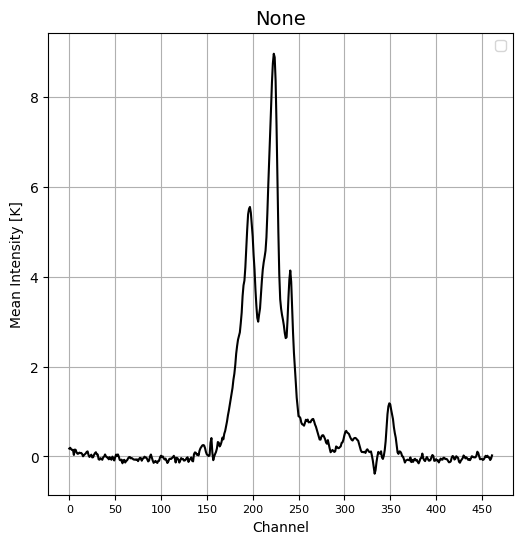

In [65]:
plot_selected_channel(nec_data, start_ch=None, end_ch=None, tittle=None, grid=50, savefig = False)

In [76]:
_data = nec_data.copy()
nec_data2 = process_data_segment(_data, vsmooth, sch_rms, ech_rms, 200, 230, sigma, thresh, integrate_layer_num)

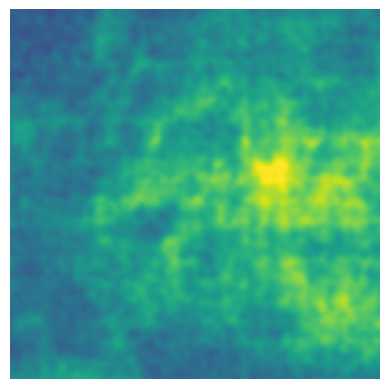

In [82]:
plt.imshow(np.nansum(gaussian_filter(nec_data[200:230]), axis=0),vmin=0, vmax=300)
plt.axis("off")
plt.savefig("nec_noise_ex.png")

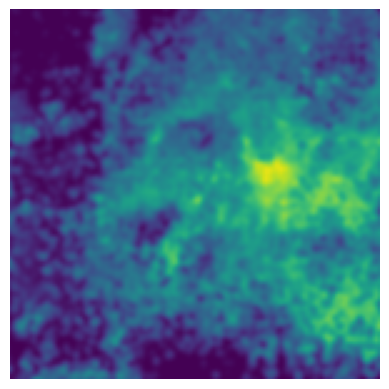

In [81]:
plt.imshow(gaussian_filter(np.nansum(nec_data2, axis=0)),vmin=0, vmax=300)
plt.axis("off")
plt.savefig("nec_noise_reduction_ex.png")